In [ ]:
!pip install transformers datasets pillow

In [ ]:
!pip install -U transformers

In [ ]:
!git clone https://github.com/watermelon-3012/sroie-ocr-ie.git
%cd sroie-ocr-ie

Cloning into 'sroie-ocr-ie'...
remote: Enumerating objects: 3646, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 3646 (delta 2), reused 4 (delta 0), pack-reused 3637 (from 1)
Receiving objects: 100% (3646/3646), 505.57 MiB | 31.72 MiB/s, done.
Resolving deltas: 100% (871/871), done.
Updating files: 100% (3616/3616), done.
/content/sroie-ocr-ie


In [ ]:
import os
import json
import torch
from PIL import Image
from pathlib import Path
from datasets import Dataset

In [ ]:
# Dataset
BASE_PATH = Path("/content/sroie-ocr-ie")

TRAIN_BOX = BASE_PATH / "data/train/box"        # txt
TRAIN_IMG = BASE_PATH / "data/train/img"        # jpg
TRAIN_ENT = BASE_PATH / "data/train/entities"   # json

In [ ]:
import re

# Normailize text
def clean_text(text):
    if text is None:
        return ""

    text = str(text)
    text = text.strip()
    text = re.sub(r"\s+", " ", text)

    return text

In [ ]:
# Build target (label)

def build_target(entity):

    company = clean_text(entity.get("company",""))
    date = clean_text(entity.get("date",""))
    address = clean_text(entity.get("address",""))
    total = clean_text(entity.get("total",""))

    target = (
        "<s_receipt>"
        f"<s_company>{company}</s_company>"
        f"<s_date>{date}</s_date>"
        f"<s_address>{address}</s_address>"
        f"<s_total>{total}</s_total>"
        "</s_receipt>"
    )

    return target

In [ ]:
# Parse data
import pandas as pd

data = []
for file in os.listdir(TRAIN_ENT):
    if not file.endswith(".json"):
        continue

    name = file.replace(".json","")
    img_path = TRAIN_IMG / f"{name}.jpg"
    ent_path = TRAIN_ENT / file

    if not img_path.exists():
        continue

    with open(ent_path, "r", encoding="utf-8") as f:
        entity = json.load(f)

    target = build_target(entity)
    data.append({
        "image_path": str(img_path),
        "target": target
    })

df = pd.DataFrame(data)

print("Total samples:", len(df))
df.head()

Total samples: 626


,image_path,target
0,/content/sroie-ocr-ie/data/train/img/154.jpg,<s_receipt><s_company>KHE ELECTRICAL TRADING</...
1,/content/sroie-ocr-ie/data/train/img/503.jpg,<s_receipt><s_company>SANYU STATIONERY SHOP</s...
2,/content/sroie-ocr-ie/data/train/img/041.jpg,<s_receipt><s_company>THREE STOOGES</s_company...
3,/content/sroie-ocr-ie/data/train/img/044.jpg,<s_receipt><s_company>UNIHAKKA INTERNATIONAL S...
4,/content/sroie-ocr-ie/data/train/img/272.jpg,<s_receipt><s_company>BROADVIEW MARKETING SDN ...


In [ ]:
df

,image_path,target
0,/content/sroie-ocr-ie/data/train/img/154.jpg,<s_receipt><s_company>KHE ELECTRICAL TRADING</...
1,/content/sroie-ocr-ie/data/train/img/503.jpg,<s_receipt><s_company>SANYU STATIONERY SHOP</s...
2,/content/sroie-ocr-ie/data/train/img/041.jpg,<s_receipt><s_company>THREE STOOGES</s_company...
3,/content/sroie-ocr-ie/data/train/img/044.jpg,<s_receipt><s_company>UNIHAKKA INTERNATIONAL S...
4,/content/sroie-ocr-ie/data/train/img/272.jpg,<s_receipt><s_company>BROADVIEW MARKETING SDN ...
...,...,...
621,/content/sroie-ocr-ie/data/train/img/157.jpg,<s_receipt><s_company>GOLDEN SCOOP SDN BHD</s_...
622,/content/sroie-ocr-ie/data/train/img/280.jpg,<s_receipt><s_company>B & BEST RESTAURANT</s_c...
623,/content/sroie-ocr-ie/data/train/img/395.jpg,<s_receipt><s_company>YAM FRESH</s_company><s_...
624,/content/sroie-ocr-ie/data/train/img/526.jpg,<s_receipt><s_company>UNIHAKKA INTERNATIONAL S...


In [ ]:
# Check dataset
print(df.iloc[0]["image_path"])
print(df.iloc[0]["target"])

/content/sroie-ocr-ie/data/train/img/154.jpg
<s_receipt><s_company>KHE ELECTRICAL TRADING</s_company><s_date>22/03/2018</s_date><s_address>33-G JALAN MAJU 3/1 TAMAN LEMBAH MAJU CHERAS, 56100 KL</s_address><s_total>101.75</s_total></s_receipt>


In [ ]:
# Train and validation dataset split
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df,
    test_size=0.1,
    random_state=42
)

print("train:", len(train_df))
print("val:", len(val_df))

train: 563
val: 63


In [ ]:
# Save splitted dataset
SAVE_DIR = BASE_PATH / "donut_dataset"
SAVE_DIR.mkdir(exist_ok=True)

train_df.to_json(SAVE_DIR / "train.json", orient="records")
val_df.to_json(SAVE_DIR / "val.json", orient="records")

<s_receipt><s_company>HOME MASTER HARDWARE & ELECTRICAL</s_company><s_date>22/12/2017</s_date><s_address>NO.113G & 115G, JALAN SETIA GEMBILANG U13/BG BANDAR SETIA ALAM, 40170 BANDAR SETIA ALAM, SELANGOR.</s_address><s_total>15.90</s_total></s_receipt>


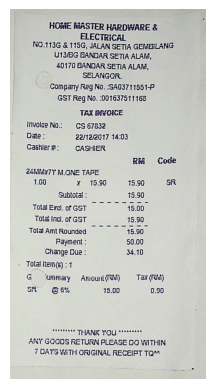

In [ ]:
# Check visually dataset

from PIL import Image
import matplotlib.pyplot as plt

sample = train_df.iloc[0]

img = Image.open(sample["image_path"])

plt.imshow(img)
plt.axis("off")

print(sample["target"])

In [ ]:
# Normalize total entity

def normalize_total(total):
    total = total.replace(",", "")
    total = total.strip()

    return total

# Model

In [ ]:
from transformers import DonutProcessor, VisionEncoderDecoderModel

MODEL_NAME = "naver-clova-ix/donut-base"

processor = DonutProcessor.from_pretrained(MODEL_NAME)

model = VisionEncoderDecoderModel.from_pretrained(MODEL_NAME)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/362 [00:00<?, ?B/s]

The image processor of type `DonutImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/518 [00:00<?, ?B/s]

...

added_tokens.json:   0%|          | 0.00/71.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/355 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/809M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/484 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


In [ ]:
# Add special tokens

special_tokens = [
"<s_receipt>",
"</s_receipt>",
"<s_company>",
"</s_company>",
"<s_date>",
"</s_date>",
"<s_address>",
"</s_address>",
"<s_total>",
"</s_total>"
]

processor.tokenizer.add_tokens(special_tokens)
model.decoder.resize_token_embeddings(len(processor.tokenizer))

The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


model.safetensors:   0%|          | 0.00/809M [00:00<?, ?B/s]

The new lm_head weights will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


MBartScaledWordEmbedding(57535, 1024, padding_idx=1)

In [ ]:
processor.image_processor.size = {
"height": 1280,
"width": 960
}

processor.image_processor.do_align_long_axis = True

In [ ]:
import torch
from torch.utils.data import Dataset
from PIL import Image

class DonutDataset(Dataset):

    def __init__(self, df, processor):
        self.df = df.reset_index(drop=True)
        self.processor = processor

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        # load image
        image = Image.open(row["image_path"]).convert("RGB")

        # image preprocessing
        pixel_values = self.processor(
            image,
            return_tensors="pt"
        ).pixel_values.squeeze(0)

        # tokenize target
        labels = self.processor.tokenizer(
            row["target"],
            add_special_tokens=False,
            return_tensors="pt"
        ).input_ids.squeeze(0)

        # ignore padding in loss
        labels[labels == self.processor.tokenizer.pad_token_id] = -100

        return {
            "pixel_values": pixel_values,
            "labels": labels
        }

In [ ]:
train_dataset = DonutDataset(train_df, processor)
val_dataset = DonutDataset(val_df, processor)

In [ ]:
sample = train_dataset[0]

print(sample["pixel_values"].min())
print(sample["pixel_values"].max())

tensor(-1.)
tensor(1.)


In [ ]:
import torch

class CustomDataCollator:
    def __init__(self, processor):
        self.processor = processor

    def __call__(self, features):
        pixel_values = [feature["pixel_values"] for feature in features]
        labels = [feature["labels"] for feature in features]

        # Stack pixel values
        batch_pixel_values = torch.stack(pixel_values)

        # Pad labels
        batch_labels = self.processor.tokenizer.pad(
            {"input_ids": labels},
            padding=True,
            return_tensors="pt"
        ).input_ids

        return {
            "pixel_values": batch_pixel_values,
            "labels": batch_labels
        }

# Instantiate the custom data collator
custom_data_collator = CustomDataCollator(processor)

print("CustomDataCollator class defined and instantiated.")

CustomDataCollator class defined and instantiated.


In [ ]:
from transformers import Seq2SeqTrainingArguments

training_args = Seq2SeqTrainingArguments(
  output_dir="./donut_sroie",

  per_device_train_batch_size=10,
  per_device_eval_batch_size=10,

  learning_rate=3e-5,

  num_train_epochs=10,

  fp16=True,

  logging_steps=50,
  eval_strategy="epoch",
  save_strategy="epoch",
  load_best_model_at_end=True,
  predict_with_generate=True
)

In [ ]:
import transformers
print(transformers.__version__)

5.3.0


In [ ]:
from transformers import Seq2SeqTrainer

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=custom_data_collator # Use the custom data collator here
)

In [ ]:
model.config.pad_token_id = processor.tokenizer.pad_token_id
model.config.decoder_start_token_id = processor.tokenizer.bos_token_id

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss
1,4.965063,2.362086
2,2.027857,1.110378
3,0.875556,0.379146
4,0.335830,0.236376
5,0.183918,0.168049
6,0.099219,0.130011
7,0.053853,0.132184
8,0.028498,0.138279
9,0.018999,0.135113
10,0.018364,0.136634


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['decoder.lm_head.weight'].


TrainOutput(global_step=570, training_loss=0.758830665653212, metrics={'train_runtime': 515.3359, 'train_samples_per_second': 10.925, 'train_steps_per_second': 1.106, 'total_flos': 1.7604512595247104e+19, 'train_loss': 0.758830665653212, 'epoch': 10.0})

In [ ]:
trainer.state.log_history

[{'loss': 4.965062866210937,
  'grad_norm': 11.121607780456543,
  'learning_rate': 2.7421052631578946e-05,
  'epoch': 0.8771929824561403,
  'step': 50},
 {'eval_loss': 2.362086296081543,
  'eval_runtime': 4.0676,
  'eval_samples_per_second': 15.488,
  'eval_steps_per_second': 1.721,
  'epoch': 1.0,
  'step': 57},
 {'loss': 2.027856903076172,
  'grad_norm': 5.205075740814209,
  'learning_rate': 2.4789473684210528e-05,
  'epoch': 1.7543859649122808,
  'step': 100},
 {'eval_loss': 1.1103776693344116,
  'eval_runtime': 4.2105,
  'eval_samples_per_second': 14.962,
  'eval_steps_per_second': 1.662,
  'epoch': 2.0,
  'step': 114},
 {'loss': 0.8755558776855469,
  'grad_norm': 4.9092326164245605,
  'learning_rate': 2.2157894736842106e-05,
  'epoch': 2.6315789473684212,
  'step': 150},
 {'eval_loss': 0.3791460394859314,
  'eval_runtime': 4.0254,
  'eval_samples_per_second': 15.651,
  'eval_steps_per_second': 1.739,
  'epoch': 3.0,
  'step': 171},
 {'loss': 0.3358297348022461,
  'grad_norm': 1.85

In [ ]:
print(trainer.state.log_history[:5])

[{'loss': 4.965062866210937, 'grad_norm': 11.121607780456543, 'learning_rate': 2.7421052631578946e-05, 'epoch': 0.8771929824561403, 'step': 50}, {'eval_loss': 2.362086296081543, 'eval_runtime': 4.0676, 'eval_samples_per_second': 15.488, 'eval_steps_per_second': 1.721, 'epoch': 1.0, 'step': 57}, {'loss': 2.027856903076172, 'grad_norm': 5.205075740814209, 'learning_rate': 2.4789473684210528e-05, 'epoch': 1.7543859649122808, 'step': 100}, {'eval_loss': 1.1103776693344116, 'eval_runtime': 4.2105, 'eval_samples_per_second': 14.962, 'eval_steps_per_second': 1.662, 'epoch': 2.0, 'step': 114}, {'loss': 0.8755558776855469, 'grad_norm': 4.9092326164245605, 'learning_rate': 2.2157894736842106e-05, 'epoch': 2.6315789473684212, 'step': 150}]


In [ ]:
import pandas as pd

logs = trainer.state.log_history
df = pd.DataFrame(logs)

print(df.head())

       loss  grad_norm  learning_rate     epoch  step  eval_loss  \
0  4.965063  11.121608       0.000027  0.877193    50        NaN   
1       NaN        NaN            NaN  1.000000    57   2.362086   
2  2.027857   5.205076       0.000025  1.754386   100        NaN   
3       NaN        NaN            NaN  2.000000   114   1.110378   
4  0.875556   4.909233       0.000022  2.631579   150        NaN   

   eval_runtime  eval_samples_per_second  eval_steps_per_second  \
0           NaN                      NaN                    NaN   
1        4.0676                   15.488                  1.721   
2           NaN                      NaN                    NaN   
3        4.2105                   14.962                  1.662   
4           NaN                      NaN                    NaN   

   train_runtime  train_samples_per_second  train_steps_per_second  \
0            NaN                       NaN                     NaN   
1            NaN                       NaN      

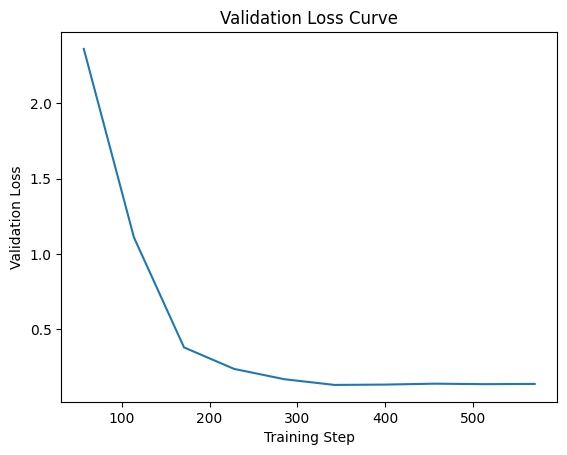

In [ ]:
eval_loss = df[df["eval_loss"].notna()]

plt.figure()
plt.plot(eval_loss["step"], eval_loss["eval_loss"])
plt.xlabel("Training Step")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Curve")
plt.show()

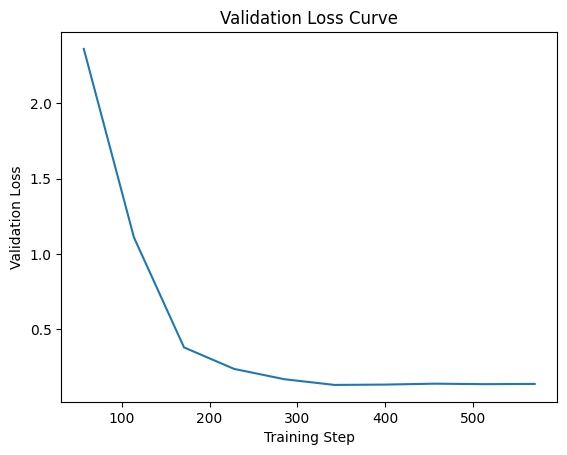

In [ ]:
eval_loss = df[df["eval_loss"].notna()]

plt.figure()
plt.plot(eval_loss["step"], eval_loss["eval_loss"])
plt.xlabel("Training Step")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Curve")
plt.show()

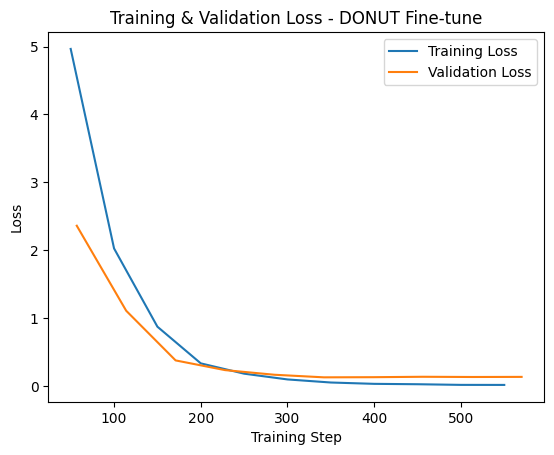

In [ ]:
plt.figure()

plt.plot(train_loss["step"], train_loss["loss"], label="Training Loss")
plt.plot(eval_loss["step"], eval_loss["eval_loss"], label="Validation Loss")

plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("Training & Validation Loss - DONUT Fine-tune")
plt.legend()
plt.savefig("./donut_sroie_model/donut_loss_curve.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# Save model and training log
trainer.save_model("./donut_sroie_model")
processor.save_pretrained("./donut_sroie_model")

logs = trainer.state.log_history
df = pd.DataFrame(logs)

df.to_csv("training_logs.csv", index=False)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
trainer.save_state()

## Testing

In [ ]:
# Dataset
BASE_PATH = Path("/content/sroie-ocr-ie")

TEST_BOX = BASE_PATH / "data/test/box"        # txt
TEST_IMG = BASE_PATH / "data/test/img"        # jpg
TEST_ENT = BASE_PATH / "data/test/entities"   # json

In [ ]:
model.eval()
model.cuda()

VisionEncoderDecoderModel(
  (encoder): DonutSwinModel(
    (embeddings): DonutSwinEmbeddings(
      (patch_embeddings): DonutSwinPatchEmbeddings(
        (projection): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
      )
      (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): DonutSwinEncoder(
      (layers): ModuleList(
        (0): DonutSwinStage(
          (blocks): ModuleList(
            (0): DonutSwinLayer(
              (layernorm_before): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
              (attention): DonutSwinAttention(
                (self): DonutSwinSelfAttention(
                  (query): Linear(in_features=128, out_features=128, bias=True)
                  (key): Linear(in_features=128, out_features=128, bias=True)
                  (value): Linear(in_features=128, out_features=128, bias=True)
                  (dropout): Dropout(p=0.0, inplace=False)
                )

In [ ]:
def predict_receipt(image_path):

    image = Image.open(image_path).convert("RGB")

    pixel_values = processor(
        image,
        return_tensors="pt"
    ).pixel_values.cuda()

    outputs = model.generate(
        pixel_values,
        max_length=512
    )

    prediction = processor.batch_decode(
        outputs,
        skip_special_tokens=True
    )[0]

    return prediction

In [ ]:
from tqdm import tqdm

predictions = {}
ground_truths = {}

image_files = list(TEST_IMG.glob("*.jpg"))

for img_path in tqdm(image_files):

    file_id = img_path.stem

    pred = predict_receipt(img_path)

    with open(TEST_ENT / f"{file_id}.json") as f:
        gt = json.load(f)

    predictions[file_id] = pred
    ground_truths[file_id] = gt

100%|██████████| 347/347 [05:49<00:00,  1.01s/it]


In [ ]:
import re

def parse_donut_output(text):

    fields = ["company", "date", "address", "total"]
    result = {}

    for f in fields:
        pattern = f"<s_{f}>(.*?)</s_{f}>"
        match = re.search(pattern, text)

        if match:
            result[f] = match.group(1).strip()
        else:
            result[f] = ""

    return result

In [ ]:
fields = ["company","date","address","total"]

correct = {f:0 for f in fields}
total = {f:0 for f in fields}

for file_id in predictions:

    pred_text = predictions[file_id]
    gt = ground_truths[file_id]

    pred = parse_donut_output(pred_text)

    for f in fields:

        total[f] += 1

        p = pred.get(f,"").lower().strip()
        g = gt.get(f,"").lower().strip()

        if p == g:
            correct[f] += 1

for f in fields:
    acc = correct[f]/total[f]
    print(f"{f}: {acc:.3f}")

company: 0.775
date: 0.816
address: 0.550
total: 0.703


In [ ]:
file_id = list(predictions.keys())[0]

print("PREDICTION:")
print(predictions[file_id])

print("\nGROUND TRUTH:")
print(ground_truths[file_id])

PREDICTION:
<s_receipt><s_company> UNIHAKKA INTERNATIONAL SDN BHD</s_company><s_date> 07 JUN 2018</s_date><s_address> 12, JALAN TAMPOI 7/4,KAWASAN PERINDUSTRIAN TAMPOI,81200 JOHOR BAHRU,JOHOR</s_address><s_total> RM30</s_total></s_receipt>

GROUND TRUTH:
{'company': 'UNIHAKKA INTERNATIONAL SDN BHD', 'date': '07 JUN 2018', 'address': '12, JALAN TAMPOI 7/4,KAWASAN PERINDUSTRIAN TAMPOI,81200 JOHOR BAHRU,JOHOR', 'total': 'RM8.20'}


In [ ]:
!pip install python-Levenshtein

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 88.6 MB/s eta 0:00:00


In [ ]:
import re
import Levenshtein

fields = ["company", "date", "address", "total"]

def parse_donut_output(text):
    result = {}
    for f in fields:
        pattern = f"<s_{f}>(.*?)</s_{f}>"
        match = re.search(pattern, text)
        if match:
            result[f] = match.group(1).strip()
        else:
            result[f] = ""
    return result


def normalize(x):
    return str(x).lower().strip()


correct = 0
total_pred = 0
total_gt = 0

field_correct = {f:0 for f in fields}
field_total = {f:0 for f in fields}

lev_scores = []

for file_id in predictions:

    pred_text = predictions[file_id]
    gt = ground_truths[file_id]

    pred = parse_donut_output(pred_text)

    for f in fields:

        p = normalize(pred.get(f,""))
        g = normalize(gt.get(f,""))

        field_total[f] += 1

        if p == g:
            field_correct[f] += 1
            correct += 1

        total_pred += 1
        total_gt += 1

        # Levenshtein similarity
        if len(p) > 0 or len(g) > 0:
            sim = 1 - Levenshtein.distance(p,g) / max(len(p),len(g))
            lev_scores.append(sim)


precision = correct / total_pred
recall = correct / total_gt
f1 = 2 * precision * recall / (precision + recall)

print("===== Field Accuracy =====")
for f in fields:
    acc = field_correct[f] / field_total[f]
    print(f"{f}: {acc:.3f}")

print("\n===== Entity Metrics =====")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1 Score: {f1:.3f}")

print("\n===== Levenshtein Similarity =====")
print(f"Average Similarity: {sum(lev_scores)/len(lev_scores):.3f}")

===== Field Accuracy =====
company: 0.775
date: 0.816
address: 0.550
total: 0.703

===== Entity Metrics =====
Precision: 0.711
Recall: 0.711
F1 Score: 0.711

===== Levenshtein Similarity =====
Average Similarity: 0.898


In [ ]:
results = []

for file_id in predictions:

    pred = parse_donut_output(predictions[file_id])
    gt = ground_truths[file_id]

    row = {
        "file_id": file_id,

        "pred_company": pred.get("company",""),
        "gt_company": gt.get("company",""),

        "pred_date": pred.get("date",""),
        "gt_date": gt.get("date",""),

        "pred_address": pred.get("address",""),
        "gt_address": gt.get("address",""),

        "pred_total": pred.get("total",""),
        "gt_total": gt.get("total",""),
    }

    results.append(row)

In [ ]:
# Save result
test_df = pd.DataFrame(results)
test_df.to_csv("/content/sroie-ocr-ie/donut_sroie_model/donut_sroie/test_predictions.csv", index=False)

In [ ]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	donut_sroie_model/

nothing added to commit but untracked files present (use "git add" to track)


In [ ]:
!git add .

fatal: not a git repository (or any of the parent directories): .git


In [ ]:
!git commit -m "Donut Fine-tune"

In [ ]:
!git push origin main